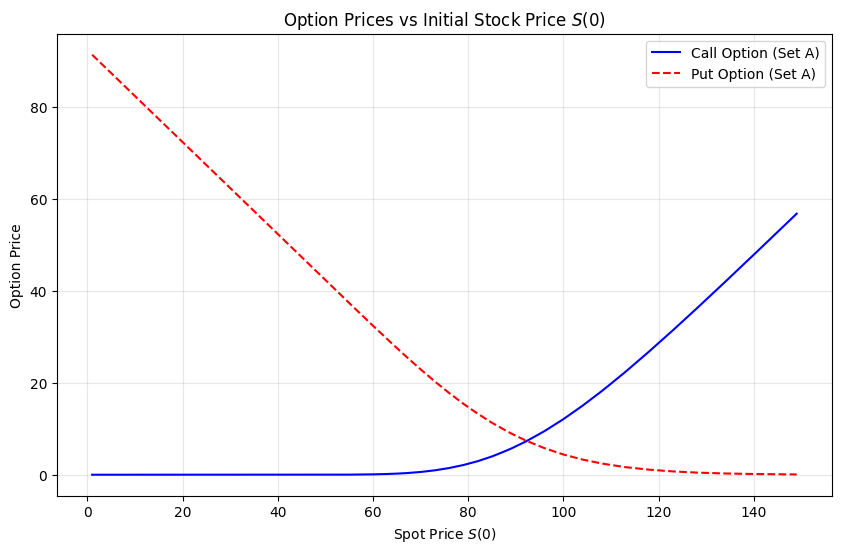

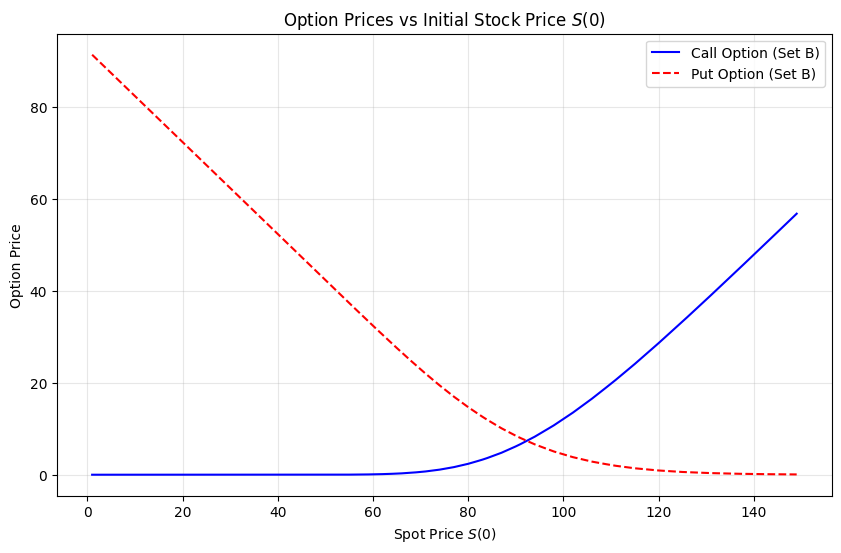

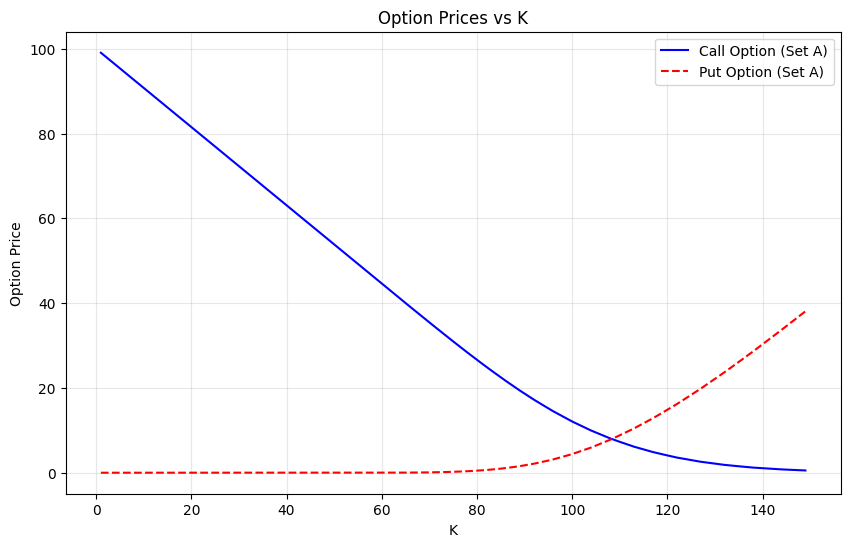

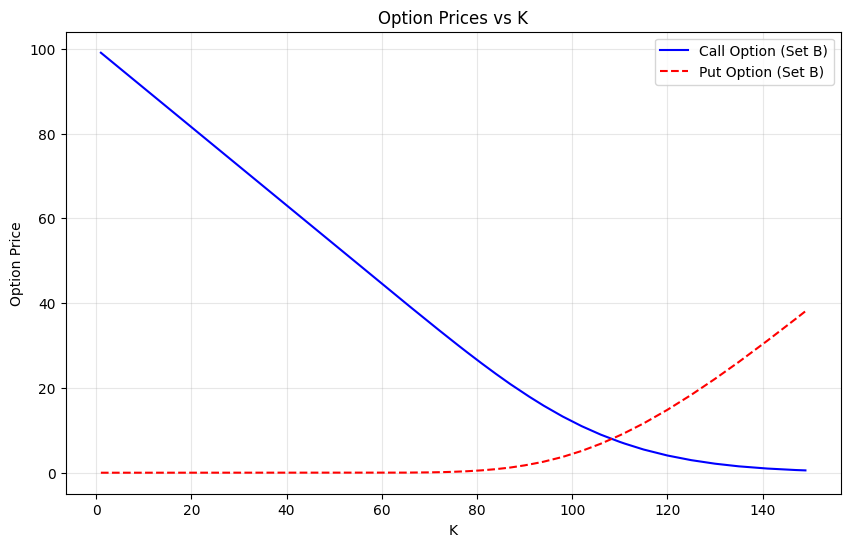

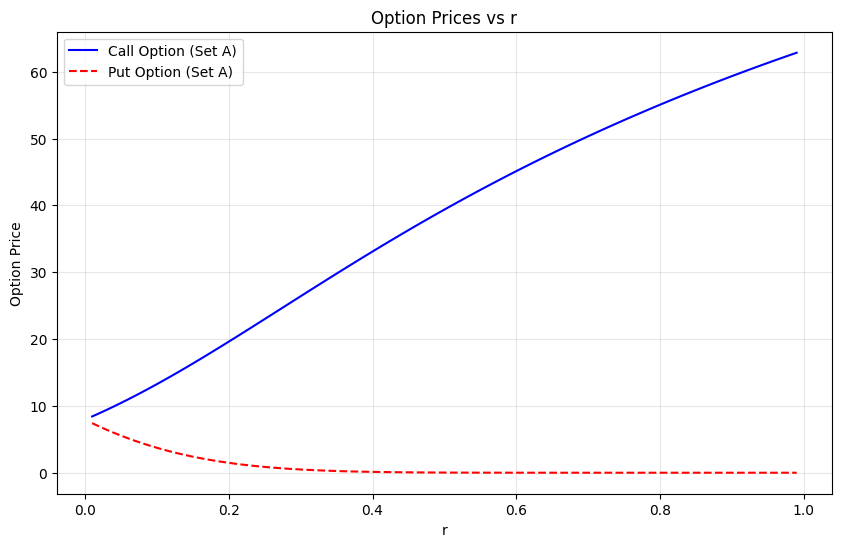

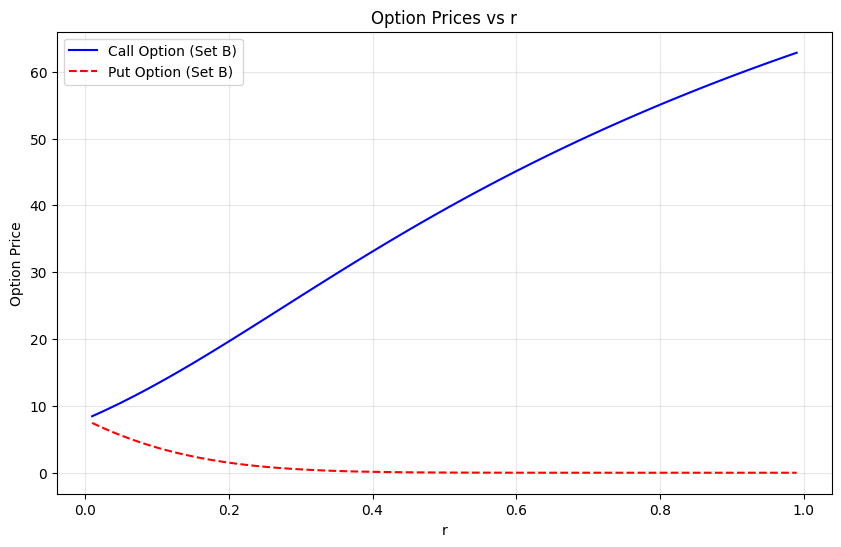

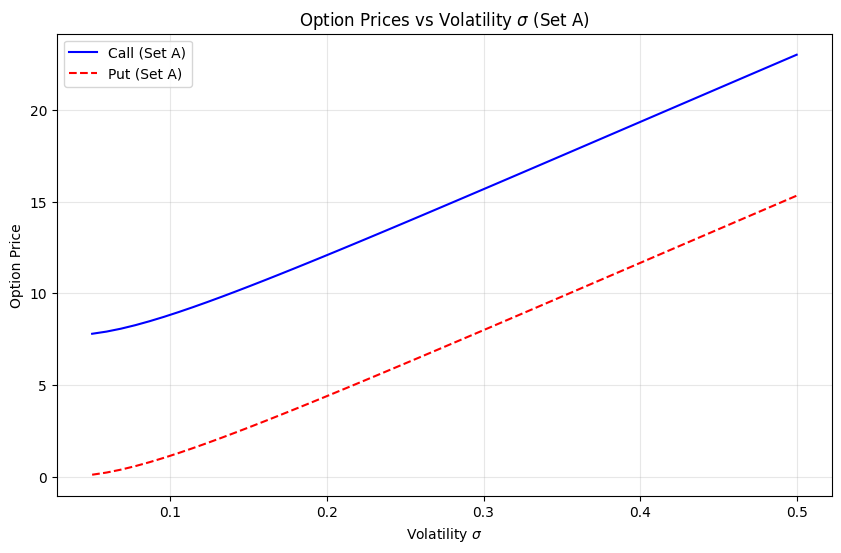

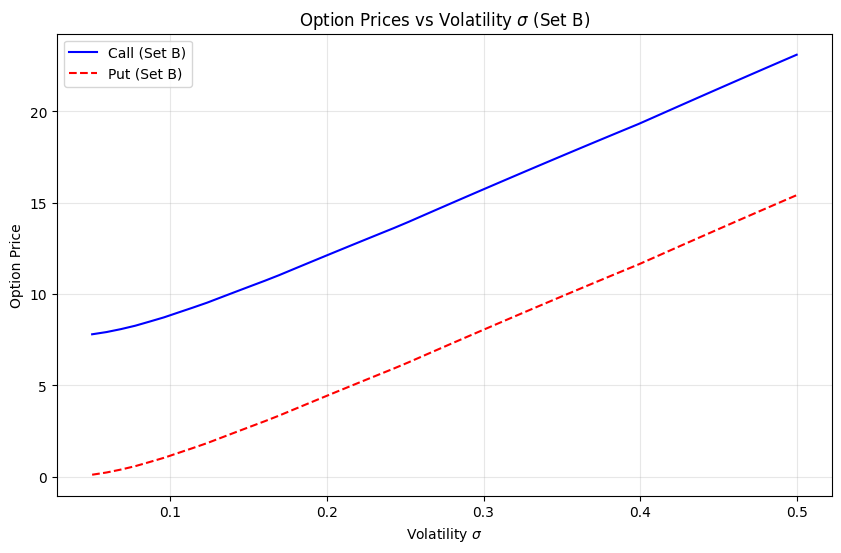

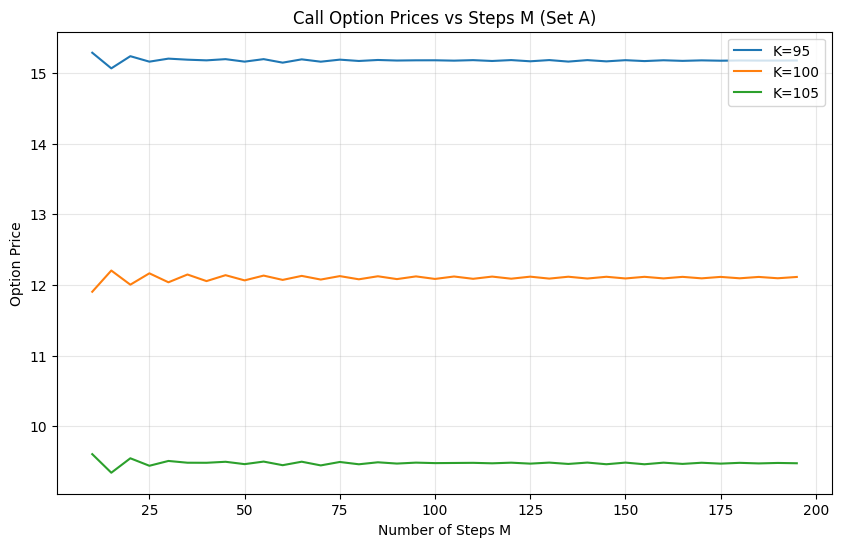

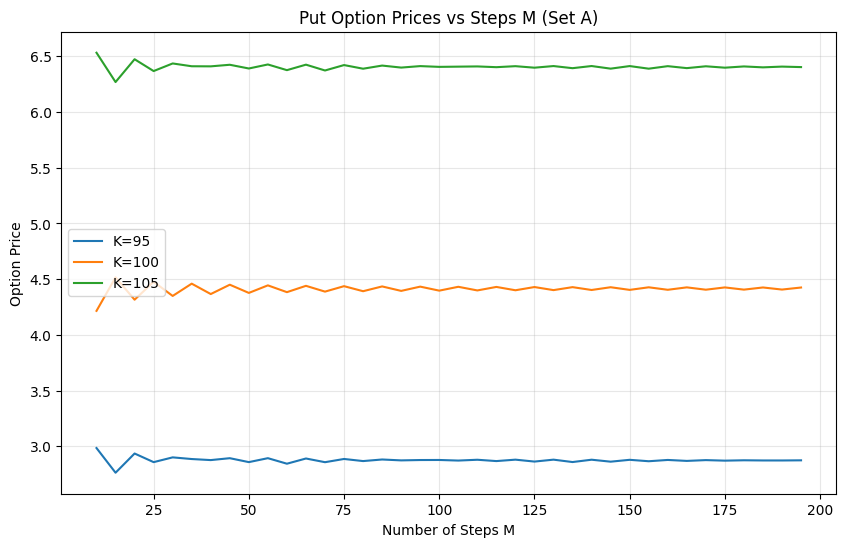

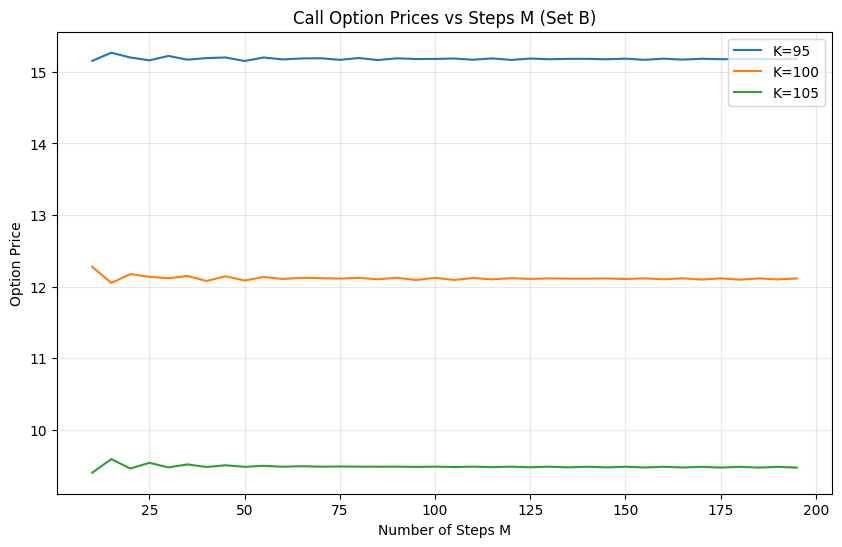

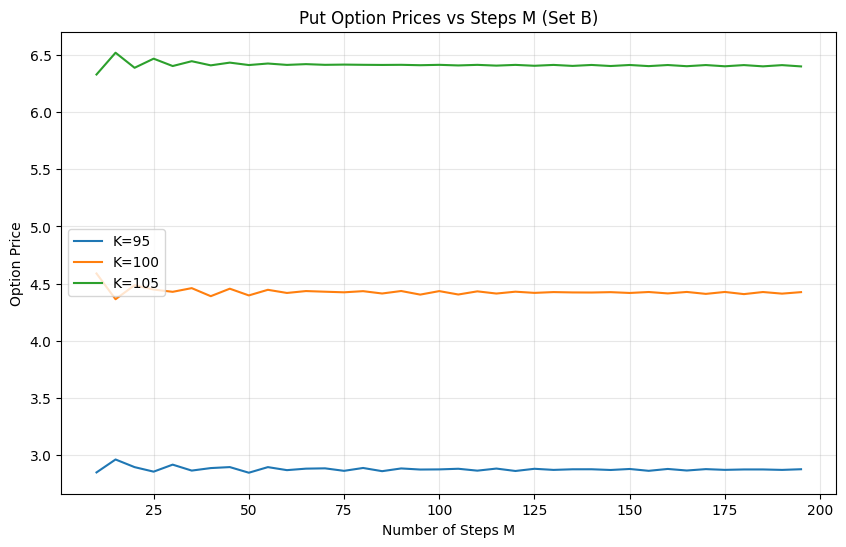

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def calculator(S_0,K,r,sigma,T,M,u,d):
    dt = T / M
    discount = np.exp(-r*dt)
    rate = np.exp(r*dt)
    p = (rate-d)/(u-d)
    
    lol=[]
    p=(rate-d)/(u-d)
    lol.append([S_0])
    for i in range(1,M+1):
        new_list=[]
        curr_list=lol[i-1]
        for j in range(len(lol[i-1])):
            new_list.append(curr_list[j]*u)
        new_list.append(curr_list[len(curr_list)-1]*d)
        lol.append(new_list)
    #backtrack
    end_value=[]
    end_value_put=[]
    for i in range(len(lol[-1])):
        end_value.append(max(lol[-1][i]-K,0))
        end_value_put.append(max(K-lol[-1][i],0))
    curr_val=end_value
    curr_val_put=end_value_put
    new_val=[]
    new_val_put=[]
    for i in range(M):
        for j in range(len(curr_val)-1):
            new_val.append(discount*(p*curr_val[j]+(1-p)*curr_val[j+1]))
        curr_val=new_val
        new_val=[]
    for i in range(M):
        for j in range(len(curr_val_put)-1):
            new_val_put.append(discount*(p*curr_val_put[j]+(1-p)*curr_val_put[j+1]))
        curr_val_put=new_val_put
        new_val_put=[]
    final=[curr_val[0],curr_val_put[0]]
    return final

S_0=100
K=100
T=1
M=100
r=0.08
sigma=0.2
difft=T/M

discount=np.exp(-r*difft)
#set A:
uA=np.exp(sigma*np.sqrt(difft))
dA=np.exp(-sigma*np.sqrt(difft))
#set B:
uB=np.exp((sigma*np.sqrt(difft))+(r-0.5*(sigma*sigma))*difft)
dB=np.exp(-(sigma*np.sqrt(difft))+(r-0.5*(sigma*sigma))*difft)

#part a
Ss=range(1,150)
callsA_S=[]
putsA_S=[]
callsB_S=[]
putsB_S=[]
for s in Ss:
    get=calculator(s,K,r,sigma,T,M,uA,dA)
    callsA_S.append(get[0])
    putsA_S.append(get[1])
for s in Ss:
    get=calculator(s,K,r,sigma,T,M,uB,dB)
    callsB_S.append(get[0])
    putsB_S.append(get[1])
plt.figure(figsize=(10,6))

# Use the list range directly for the X-axis
plt.plot(Ss,callsA_S,label='Call Option (Set A)',color='blue')
plt.plot(Ss,putsA_S,label='Put Option (Set A)',color='red',linestyle='--')

plt.title('Option Prices vs Initial Stock Price $S(0)$')
plt.xlabel('Spot Price $S(0)$')
plt.ylabel('Option Price')
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()

plt.figure(figsize=(10,6))

# Use the list range directly for the X-axis
plt.plot(Ss,callsB_S,label='Call Option (Set B)',color='blue')
plt.plot(Ss,putsB_S,label='Put Option (Set B)',color='red',linestyle='--')

plt.title('Option Prices vs Initial Stock Price $S(0)$')
plt.xlabel('Spot Price $S(0)$')
plt.ylabel('Option Price')
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()

#part b: K

Ks=range(1,150)
callsA_S=[]
putsA_S=[]
callsB_S=[]
putsB_S=[]
for k in Ks:
    get=calculator(S_0,k,r,sigma,T,M,uA,dA)
    callsA_S.append(get[0])
    putsA_S.append(get[1])
for k in Ks:
    get=calculator(S_0,k,r,sigma,T,M,uB,dB)
    callsB_S.append(get[0])
    putsB_S.append(get[1])
plt.figure(figsize=(10,6))

plt.plot(Ks,callsA_S,label='Call Option (Set A)',color='blue')
plt.plot(Ks,putsA_S,label='Put Option (Set A)',color='red',linestyle='--')

plt.title('Option Prices vs K')
plt.xlabel('K')
plt.ylabel('Option Price')
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()

plt.figure(figsize=(10,6))

plt.plot(Ks,callsB_S,label='Call Option (Set B)',color='blue')
plt.plot(Ks,putsB_S,label='Put Option (Set B)',color='red',linestyle='--')

plt.title('Option Prices vs K')
plt.xlabel('K')
plt.ylabel('Option Price')
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()



#part c: r


rs=np.linspace(0.01,0.99,100)
callsA_S=[]
putsA_S=[]
callsB_S=[]
putsB_S=[]
for rr in rs:
    get=calculator(S_0,K,rr,sigma,T,M,uA,dA)
    callsA_S.append(get[0])
    putsA_S.append(get[1])
for rr in rs:
    get=calculator(S_0,K,rr,sigma,T,M,uB,dB)
    callsB_S.append(get[0])
    putsB_S.append(get[1])
plt.figure(figsize=(10,6))

plt.plot(rs,callsA_S,label='Call Option (Set A)',color='blue')
plt.plot(rs,putsA_S,label='Put Option (Set A)',color='red',linestyle='--')

plt.title('Option Prices vs r')
plt.xlabel('r')
plt.ylabel('Option Price')
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()

plt.figure(figsize=(10,6))

plt.plot(rs,callsB_S,label='Call Option (Set B)',color='blue')
plt.plot(rs,putsB_S,label='Put Option (Set B)',color='red',linestyle='--')

plt.title('Option Prices vs r')
plt.xlabel('r')
plt.ylabel('Option Price')
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()

sigmas=np.linspace(0.05,0.5,50)
callsA_sig=[]
putsA_sig=[]
callsB_sig=[]
putsB_sig=[]

for sig in sigmas:
    uA_new=np.exp(sig*np.sqrt(difft))
    dA_new=np.exp(-sig*np.sqrt(difft))
    
    getA=calculator(S_0,K,r,sig,T,M,uA_new,dA_new)
    callsA_sig.append(getA[0])
    putsA_sig.append(getA[1])
    
    uB_new=np.exp(sig*np.sqrt(difft)+(r-0.5*sig**2)*difft)
    dB_new=np.exp(-sig*np.sqrt(difft)+(r-0.5*sig**2)*difft)
    
    getB=calculator(S_0,K,r,sig,T,M,uB_new,dB_new)
    callsB_sig.append(getB[0])
    putsB_sig.append(getB[1])

plt.figure(figsize=(10,6))
plt.plot(sigmas,callsA_sig,label='Call (Set A)',color='blue')
plt.plot(sigmas,putsA_sig,label='Put (Set A)',color='red',linestyle='--')
plt.title(r'Option Prices vs Volatility $\sigma$ (Set A)')
plt.xlabel(r'Volatility $\sigma$')
plt.ylabel('Option Price')
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()

plt.figure(figsize=(10,6))
plt.plot(sigmas,callsB_sig,label='Call (Set B)',color='blue')
plt.plot(sigmas,putsB_sig,label='Put (Set B)',color='red',linestyle='--')
plt.title(r'Option Prices vs Volatility $\sigma$ (Set B)')
plt.xlabel(r'Volatility $\sigma$')
plt.ylabel('Option Price')
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()



Ms=range(10,200,5) 
Ks=[95,100,105]

callsA_M={95:[],100:[],105:[]}
putsA_M={95:[],100:[],105:[]}
callsB_M={95:[],100:[],105:[]}
putsB_M={95:[],100:[],105:[]}

for k in Ks:
    for m in Ms:
        dt_new=T/m
        
        uA_new=np.exp(sigma*np.sqrt(dt_new))
        dA_new=np.exp(-sigma*np.sqrt(dt_new))
        getA=calculator(S_0,k,r,sigma,T,m,uA_new,dA_new)
        callsA_M[k].append(getA[0])
        putsA_M[k].append(getA[1])
        
        uB_new=np.exp((sigma*np.sqrt(dt_new))+(r-0.5*(sigma*sigma))*dt_new)
        dB_new=np.exp(-(sigma*np.sqrt(dt_new))+(r-0.5*(sigma*sigma))*dt_new)
        
        getB=calculator(S_0,k,r,sigma,T,m,uB_new,dB_new)
        callsB_M[k].append(getB[0])
        putsB_M[k].append(getB[1])

plt.figure(figsize=(10,6))
plt.plot(Ms,callsA_M[95],label='K=95')
plt.plot(Ms,callsA_M[100],label='K=100')
plt.plot(Ms,callsA_M[105],label='K=105')
plt.title('Call Option Prices vs Steps M (Set A)')
plt.xlabel('Number of Steps M')
plt.ylabel('Option Price')
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()

plt.figure(figsize=(10,6))
plt.plot(Ms,putsA_M[95],label='K=95')
plt.plot(Ms,putsA_M[100],label='K=100')
plt.plot(Ms,putsA_M[105],label='K=105')
plt.title('Put Option Prices vs Steps M (Set A)')
plt.xlabel('Number of Steps M')
plt.ylabel('Option Price')
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()

plt.figure(figsize=(10,6))
plt.plot(Ms,callsB_M[95],label='K=95')
plt.plot(Ms,callsB_M[100],label='K=100')
plt.plot(Ms,callsB_M[105],label='K=105')
plt.title('Call Option Prices vs Steps M (Set B)')
plt.xlabel('Number of Steps M')
plt.ylabel('Option Price')
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()

plt.figure(figsize=(10,6))
plt.plot(Ms,putsB_M[95],label='K=95')
plt.plot(Ms,putsB_M[100],label='K=100')
plt.plot(Ms,putsB_M[105],label='K=105')
plt.title('Put Option Prices vs Steps M (Set B)')
plt.xlabel('Number of Steps M')
plt.ylabel('Option Price')
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()

In [18]:
def lookback_calculator(S_0,T,r,sigma,M,u,d):
    dt = T / M            
    discount = np.exp(-r*dt)
    rate = np.exp(r*dt)
    p = (rate-d)/(u-d)
    lol=[]
    lol.append({(S_0,S_0)})
    for i in range(1,M+1):
        new_list=set()
        curr_list=lol[i-1] #next time use lol[-1] for last entry
        for state in curr_list:
            new_max1=max(state[0]*u,state[1])
            new_max2=max(state[0]*d,state[1])
            new_list.add((state[0]*u,new_max1))
            new_list.add((state[0]*d,new_max2))
        lol.append(new_list)
    #backtrack
    values={}
    for state in lol[-1]:
        values[state]=max(state[1]-state[0],0)
    
    
    for i in range(M-1,-1,-1):
        curr_val=values
        values={}
        for state in lol[i]:
            s_curr=state[0]
            m_curr=state[1]            
            s_up=s_curr*u
            m_up=max(s_up,m_curr)
            val_up=curr_val[(s_up,m_up)] 
            
            s_down=s_curr*d
            m_down=max(s_down,m_curr)
            val_down=curr_val[(s_down,m_down)] 
            
            option_val=discount*(p*val_up+(1-p)*val_down)
            values[state]=option_val
            
    return values[(S_0,S_0)]




S_0=100
T=1
r=0.08
sigma=0.2

# part a
Ms=[5,10,25,50]
print(f"{'M':<5} | {'Option Price'}")
print("-"*20)

for m in Ms:
    difft=T / m
    u=np.exp(sigma*np.sqrt(difft)+(r-0.5*sigma**2)*difft)
    d=np.exp(-sigma*np.sqrt(difft)+(r-0.5*sigma**2)*difft)
    
    price=lookback_calculator(S_0,T,r,sigma,m,u,d)
    print(f"{m} | {price}")


# Part c
S_0=100
T=1
r=0.08
sigma=0.2
M=5

dt=T / M
u=np.exp(sigma*np.sqrt(dt)+(r-0.5*sigma**2)*dt)
d=np.exp(-sigma*np.sqrt(dt)+(r-0.5*sigma**2)*dt)

discount=np.exp(-r*dt)
rate=np.exp(r*dt)
p=(rate-d) / (u-d)

# 1. Forward
lol=[]
lol.append([(S_0,S_0)]) 

for i in range(M):
    prev_level=lol[-1]
    new_level=[]
    for state in prev_level:
        s_curr,m_curr=state
        
        # UP Child (index 2*j)
        s_up=s_curr*u
        m_up=max(s_up,m_curr)
        new_level.append((s_up,m_up))
        
        # DOWN Child (index 2*j+1)
        s_down=s_curr*d
        m_down=max(s_down,m_curr)
        new_level.append((s_down,m_down))
        
    lol.append(new_level)

# 2. Backward
opt_values=[[] for _ in range(M+1)]

for state in lol[M]:
    payoff=max(state[1]-state[0],0)
    opt_values[M].append(payoff)

for i in range(M-1,-1,-1):
    num_nodes=len(lol[i])
    for j in range(num_nodes):
        val_up=opt_values[i+1][2*j]
        val_down=opt_values[i+1][2*j+1]
        current_val=discount*(p*val_up+(1-p)*val_down)
        opt_values[i].append(current_val)

print(f"{'Time'} | {'Price'} | {'Max'} | {'Value'}")
print("-"*45)

for i in range(M+1):
    for j in range(len(lol[i])):
        price=lol[i][j][0]
        max_val=lol[i][j][1]
        val=opt_values[i][j]
        
        print(f"{i} | {price} | {max_val} | {val}")

M     | Option Price
--------------------
5 | 9.11929898586469
10 | 10.08058290683101
25 | 11.003495335646338
50 | 11.510862222177268
Time | Price | Max | Value
---------------------------------------------
0 | 100 | 100 | 9.11929898586469
1 | 110.676651999383 | 110.676651999383 | 9.027951165547757
1 | 92.54800352077254 | 100 | 9.504839866450858
2 | 122.49321297792528 | 122.49321297792528 | 8.548076183576446
2 | 102.42903178906215 | 110.676651999383 | 9.79911875354703
2 | 102.42903178906214 | 102.42903178906214 | 7.1479157567747444
2 | 85.65132955680926 | 100 | 12.168664659721797
3 | 135.57138705044142 | 135.57138705044142 | 7.416771005131012
3 | 113.3650230595177 | 122.49321297792528 | 9.95527127295782
3 | 113.3650230595177 | 113.3650230595177 | 6.201916453882752
3 | 94.79602394643446 | 110.676651999383 | 13.712862965988537
3 | 113.36502305951768 | 113.36502305951768 | 6.201916453882752
3 | 94.79602394643445 | 102.42903178906214 | 8.324614669633142
3 | 94.79602394643445 | 100 | 7.1484

In [19]:
import time as time
def efficient_algorithm(S_0,T,r,sigma,M,u,d):
    dt=T/M
    discount=np.exp(-r*dt)
    rate=np.exp(r*dt)
    p=(rate-d)/(u-d)
    
    # Track Ratios(Max/Price)
    tree=[{1.0}]
    
    # Forward (Ratios)
    for i in range(M):
        next_ratios=set()
        for R in tree[-1]:
            R_up=max(1.0,R / u)
            next_ratios.add(round(R_up,8))
            
            R_down=R/d
            next_ratios.add(round(R_down,8))
        tree.append(next_ratios)
        
    # Backward
    g_values={}
    for R in tree[-1]:
        g_values[R]=R-1.0
        
    for i in range(M-1,-1,-1):
        future_g=g_values
        g_values={}
        for R in tree[i]:
            R_up=round(max(1.0,R / u),8)
            R_down=round(R / d,8)
            
            val_up=future_g[R_up]
            val_down=future_g[R_down]
            
            new_g=discount*(p*u*val_up+(1-p)*d*val_down)
            g_values[R]=new_g
            
    return S_0*g_values[1.0]

# --- 3. The Comparison Race ---
S_0=100
T=1
r=0.08
sigma=0.2

# We test varying M
Ms=[10,20,40,60,80]
times_basic=[]
times_efficient=[]

print(f"{'M'}   |{'Basic'}      |{'Efficient'}")
print("-"*55)

for m in Ms:
    dt=T/m
    u=np.exp(sigma*np.sqrt(dt)+(r-0.5*sigma**2)*dt)
    d=np.exp(-sigma*np.sqrt(dt)+(r-0.5*sigma**2)*dt)
    
    # 1.Basic
    start=time.time()
    p1=lookback_calculator(S_0,T,r,sigma,m,u,d)
    t1=time.time()-start
    times_basic.append(t1)
    
    # 2.Efficient
    start=time.time()
    p2=efficient_algorithm(S_0,T,r,sigma,m,u,d)
    t2=time.time()-start
    times_efficient.append(t2)
    
    print(f"{m} | {t1}       | {t2}")

M   |Basic      |Efficient
-------------------------------------------------------
10 | 0.003299236297607422       | 0.004427433013916016
20 | 0.017841100692749023       | 0.02287888526916504
40 | 0.800074577331543       | 0.33156800270080566
60 | 15.81420111656189       | 1.6225802898406982
80 | 120.64964389801025       | 6.381243944168091
